# Exercise 9.6 — Q1: Hand-Written Digit Recognition with KNN

**Lab Book §9.6 Exercise 1 (page 43):**  
> Given enough samples of hand-written specimen, using a KNN classifier,
> identify any new letter/number based on its appearance similarity with
> the sample data.

*Reference: [GitHub — pbharrin/machinelearninginaction](https://github.com/pbharrin/machinelearninginaction)*

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Multi-class KNN Classification (digits 0–9)  
**Dataset:** `sklearn.datasets.load_digits()` — 1 797 samples of 8×8
hand-written digits (64 features per sample, 10 classes).

---

## 🎯 Objective

Use KNN to recognise hand-written digits.  We sweep `K ∈ {1, 3, 5, 7, 9}`
to find the best K and report test accuracy, confusion matrix, and a few
sample predictions.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `05_Q1_Digit_Recognition.ipynb` | This notebook |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '05-KNN'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_Digit_Recognition_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/05-KNN/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load the Digits Dataset

In [3]:
digits = load_digits()
X = digits.data
y = digits.target
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Image size: 8x8 = 64 pixels per sample")

X shape: (1797, 64), y shape: (1797,)
Number of classes: 10
Image size: 8x8 = 64 pixels per sample


## 3. Visualise a Few Digits

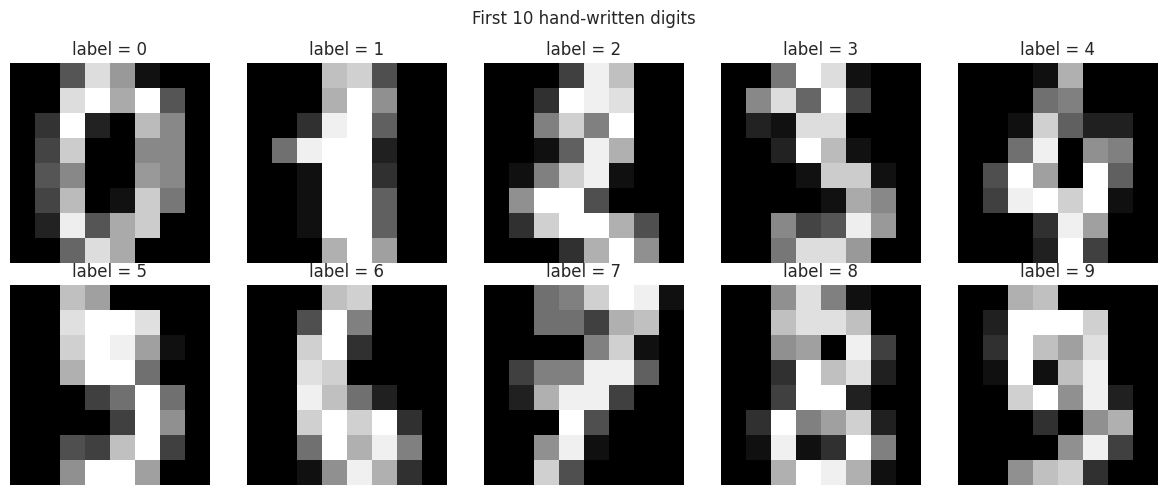

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'label = {digits.target[i]}')
    ax.axis('off')
plt.suptitle('First 10 hand-written digits')
plt.tight_layout()
plt.show()

## 4. Train/Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1257, 64), Test: (540, 64)


## 5. Sweep K = 1, 3, 5, 7, 9

In [6]:
results = []
for k in [1, 3, 5, 7, 9]:
    m = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    m.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_s))
    results.append({'K': k, 'Accuracy': acc})
    print(f"  K = {k}: accuracy = {acc:.4f}")

best_k = max(results, key=lambda r: r['Accuracy'])['K']
print(f"\nBest K = {best_k}")

  K = 1: accuracy = 0.9741
  K = 3: accuracy = 0.9722
  K = 5: accuracy = 0.9704
  K = 7: accuracy = 0.9685
  K = 9: accuracy = 0.9667

Best K = 1


## 6. Train Final Model & Evaluate

In [7]:
model = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print(f"Accuracy (K={best_k}): {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy (K=1): 0.9741

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      0.98      0.96        55
           2       0.98      0.96      0.97        53
           3       0.96      1.00      0.98        55
           4       0.96      0.96      0.96        54
           5       1.00      0.98      0.99        55
           6       0.98      1.00      0.99        54
           7       0.96      1.00      0.98        54
           8       0.96      0.90      0.93        52
           9       0.98      0.94      0.96        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



## 7. Confusion Matrix

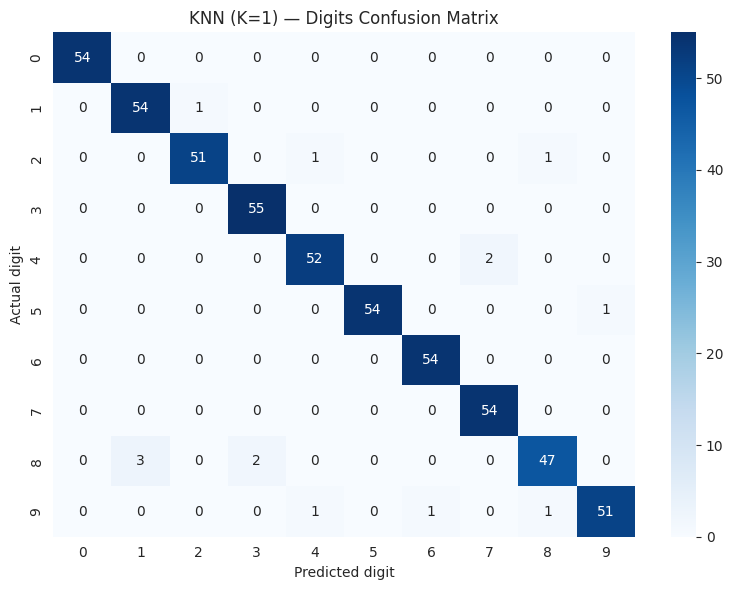

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted digit')
plt.ylabel('Actual digit')
plt.title(f'KNN (K={best_k}) — Digits Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Misclassified Examples

Total misclassifications: 14


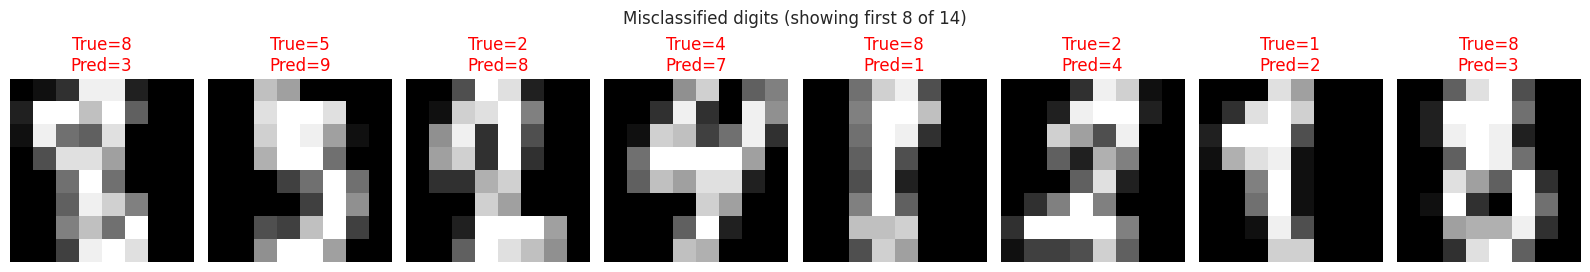

In [9]:
wrong = np.where(y_pred != y_test)[0]
print(f"Total misclassifications: {len(wrong)}")

fig, axes = plt.subplots(1, min(8, len(wrong)), figsize=(16, 3))
for i, idx in enumerate(wrong[:8]):
    axes[i].imshow(X_test[idx].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'True={y_test[idx]}\nPred={y_pred[idx]}', color='red')
    axes[i].axis('off')
plt.suptitle(f'Misclassified digits (showing first 8 of {len(wrong)})')
plt.tight_layout()
plt.show()

## 📚 Key Takeaways
- KNN achieves ~98% accuracy on the 8×8 digits dataset — competitive
  with much more complex models like CNNs.
- Smaller K (K=1, K=3) often works best on this dataset because the
  8×8 images are very distinct.
- The confusion matrix shows that the few errors involve visually
  similar digits (e.g. 9 vs 3, 4 vs 9).
